# IMPLEMENTACIÓN MÉTODO ts-MULE

Se desarrollan los códigos para lograr implementar el método ts-MULE (Schlegel et al. 2021) en el modelo entrenado mediante transfer learning para predecir, a partir de 6 series de tiempo de tsunami en boyas, la probabilidad de inundación por tsunami para la localidad de Coquimbo.

Se implementa para un dato cualquiere del conjunto de pruebas, para evaluar el comportamiento del método.

Vale la pena destacar que, como la intención del proyecto es implementar más de un método de XAI, se trabajó para ejecutar tanto el método CONFETTI (Cetina et al. 2026) como ts-MULE (Schlegel et al. 2021) en el mismo entorno virtual de conda, a pesar de que cada método fue desarrollado en versiones diferentes de Python. Para lograr lo anterior, fue necesario efectuar algunas modificaciones al os cóodigos disponibles en el repositorio github de ts-MULE, de acuerdo al detalle que se presenta. Estos cambios ya se encuentran implementados en el paquete de datos del presente repositorio.

<u>Modificaciones a los códigos de ts-MULE:<u>
- segmentation_method='slope-max' → nombre incorrecto, corregido a 'slopes-sorted'
- z_hat sin flatten en _explain() → shape (100,1) causaba coeficientes nulos
- Lasso(alpha=0.01) demasiado agresivo → reducido a alpha=0.0001
- mask_percentile() con ">" estricto → cambiado a ">=" con method='lower'

<u>Referencias:</u>
- Schlegel, U., Lam, D. V., Keim, D. A., & Seebacher, D. (2021). TS-MULE: Local Interpretable Model-Agnostic Explanations for Time Series Forecast Models. Joint European Conference on Machine Learning and Knowledge Discovery in Databases, 5–14. http://arxiv.org/abs/2109.08438
- Cetina, A. G. P., Benguessoum, K., Lourenço, R., & Kubler, S. (2026). Counterfactual Explainable AI (XAI) Method for Deep Learning-Based Multivariate Time Series Classification. Proceedings of the AAAI Conference on Artificial Intelligence, 17393–174000. http://arxiv.org/abs/2511.13237

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Add module tsmule to syspath
print("Current working dir:", os.getcwd())
sys.path.insert(0, '../XAI_for_ts/ts-mule')

# Filter out all RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning) 

import logging 
logging.getLogger("stumpy").setLevel(logging.ERROR)

Current working dir: C:\Users\asuso\Documents\UTFSM\Doctorado Ing Aplicada\Cursos\INF473 - Introducción XAI\Proyecto\2da_Entrega


In [2]:
# Add module tsmule to system path
from tsmule.xai.lime import LimeTS
from tsmule.xai.evaluation import PerturbationAnalysis
from tsmule.sampling.segment import MatrixProfileSegmentation, SAXSegmentation
from tsmule.xai.viz import visualize_segmentation_mask

In [3]:
#Cargar datos
def load_pickle(p_name):
    with open(p_name, 'rb') as file:
        # Load the data from the file
        data = pickle.load(file)
    return data

data_path = 'DATA\\'
y_test = load_pickle(data_path+'ytest_new.pickle')
X_test = load_pickle(data_path+'xtest_new.pickle')
y_train = load_pickle(data_path+'ytrain_new.pickle')
X_train = load_pickle(data_path+'xtrain_new.pickle')
y_val = load_pickle(data_path+'yval_new.pickle')
X_val = load_pickle(data_path+'xval_new.pickle')

In [4]:
#Cargar modelo
import keras
from keras.models import load_model

model = load_model('MODELS\\transfer_learned_tsunami_classifier3.keras')

C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [5]:
# Define a predict fn/model

def predict_fn(x, model=model):
    if len(x.shape) == 2:
        predictions = model.predict(x[np.newaxis]).ravel()
    if len(x.shape) == 3:
        predictions = model.predict(x).ravel()
    return predictions

In [11]:
# Trabajaremos solo con las primeras series muestras muestra
mi, mf = [0, 5]
X = X_test[mi:mf]

In [12]:
from sklearn import metrics
from datetime import datetime

#analysis_relevance — ese método es para evaluar la calidad del explicador comparando contra un conjunto de referencia con respuestas conocidas (y_test).

start = datetime.now()

explainer = LimeTS(n_samples=100)
relevance = [explainer.explain(x, predict_fn, segmentation_method='slopes-sorted') for x in X]

# PerturbationAnalysis for Percentile 
#   replacement_method = 'zeros|global_mean|local_mean|inverse_max|inverse_mean'
pa = PerturbationAnalysis()
scores = pa.analysis_relevance(X, y_test[mi:mf], relevance, 
                        predict_fn=predict_fn,
                        replace_method='zeros',  
                        eval_fn=metrics.mean_squared_error,
                        percentile=90,
                        delta=0.1
                        )
scores

end = datetime.now()
print(f'Tadró {str(end-start)} en ejecutarse')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [37]:
# x_nuevo tiene shape (n_steps, n_features) — la serie del evento actual
m = 1
x_nuevo = X_test[m:m+1]  # tu serie de tsunami en curso
X_nuevo = X_test[m]
model.predict(x_nuevo)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


array([[0.99999976]], dtype=float32)

In [46]:
# 1. Calcular relevancia para esa serie
relevance_nuevo = explainer.explain(X_nuevo, predict_fn, 
                                    segmentation_method='slopes-sorted')

# Perturbar basado en percentil 90 de relevancia
x_p90 = pa.perturb([X_nuevo], [relevance_nuevo])
x_p90 = next(x_p90)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

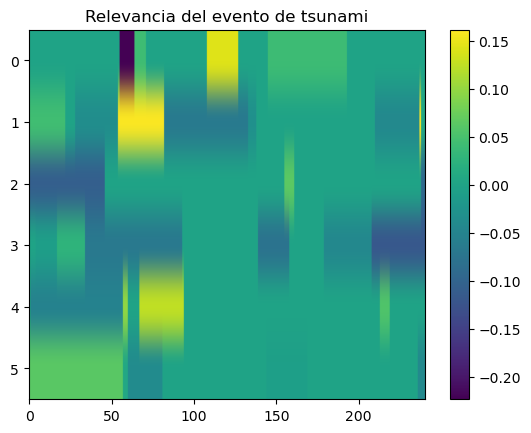

In [47]:
# 2. Visualizar qué partes de la serie son más relevantes
plt.imshow(relevance_nuevo.T, aspect='auto')
plt.title('Relevancia del evento de tsunami')
plt.colorbar()
plt.show()

C:\Users\asuso\AppData\Local\Temp\ipykernel_24204\3395332482.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


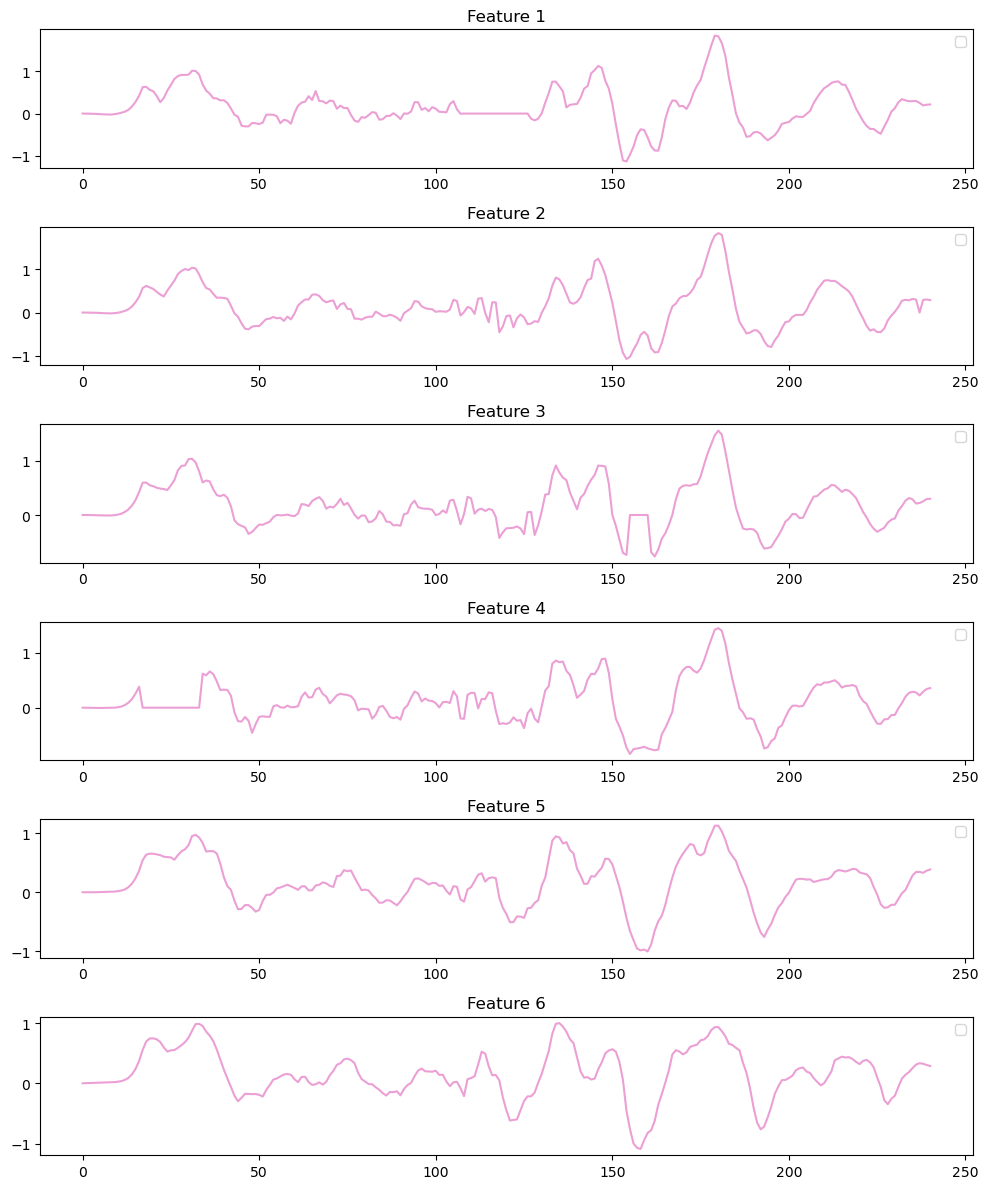

In [49]:
n_steps, features = X_nuevo.shape

# # Calcular relevancia para x_nuevo
# relevance_nuevo = explainer.explain(X_nuevo, predict_fn, 
#                                     segmentation_method='slopes-sorted')

# Perturbar basado en percentil 90 de relevancia
# x_p90 = pa.perturb([X_nuevo], [relevance_nuevo])
# x_p90 = next(x_p90)

# Graficar cada feature
fig, axes = plt.subplots(features, 1, figsize=(10, features*2))
for i in range(features):
    axes[i].plot(x_nuevo[:, i], alpha=0.7)
    axes[i].plot(x_p90[:, i], alpha=0.7)
    axes[i].set_title(f'Feature {i+1}')
    axes[i].legend()
plt.tight_layout()
plt.show()

C:\Users\asuso\AppData\Local\Temp\ipykernel_24204\1045633684.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


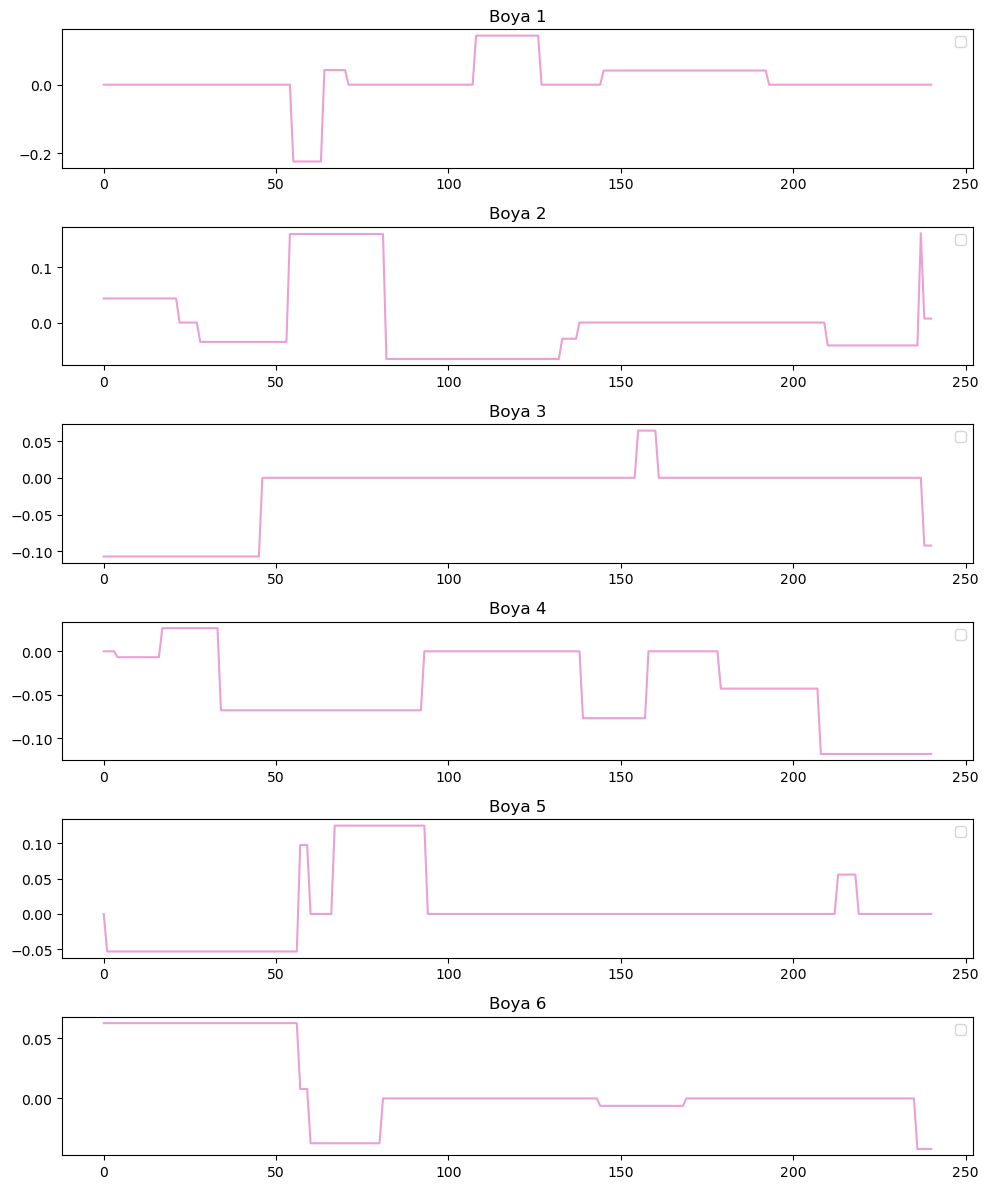

In [50]:
fig, axes = plt.subplots(features, 1, figsize=(10, features*2))
for i in range(features):
    axes[i].plot(x_nuevo[:, i], alpha=0.7)
    axes[i].plot(relevance_nuevo[:, i], alpha=0.7)
    axes[i].set_title(f'Boya {i+1}')
    axes[i].legend()
plt.tight_layout()
plt.show()

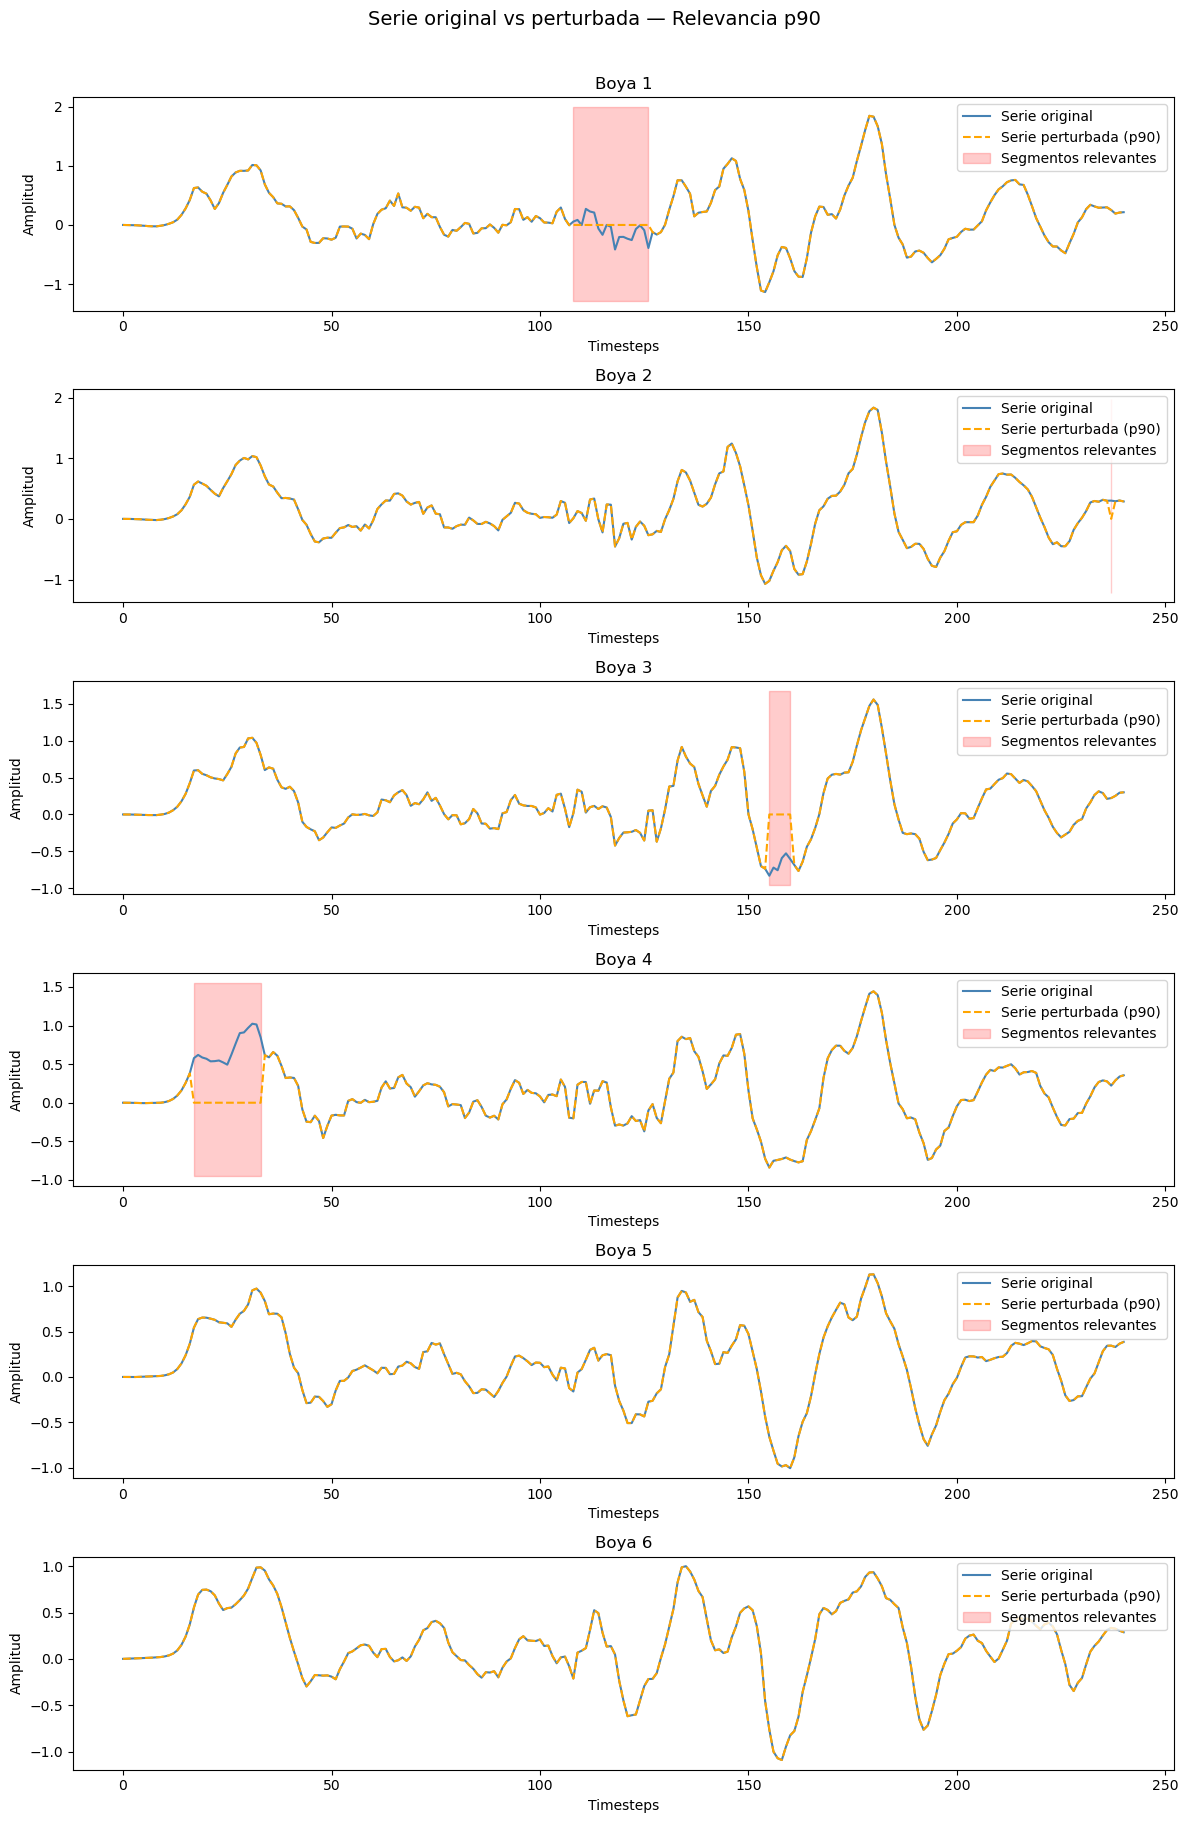

In [51]:
# n_steps, features = X_nuevo.shape

# Calcular serie perturbada
# x_p90 = pa.perturb([X_nuevo], [relevance_nuevo])
# x_p90 = next(x_p90)

fig, axes = plt.subplots(features, 1, figsize=(12, features*3))
for i in range(features):
    axes[i].plot(X_nuevo[:, i], 
                 label='Serie original', 
                 color='steelblue', linewidth=1.5)
    axes[i].plot(x_p90[:, i], 
                 label='Serie perturbada (p90)', 
                 color='orange', linewidth=1.5, linestyle='--')
    
    # Sombrear las regiones relevantes (donde difieren)
    diff = np.abs(X_nuevo[:, i] - x_p90[:, i]) > 1e-10
    axes[i].fill_between(range(n_steps), 
                         axes[i].get_ylim()[0], axes[i].get_ylim()[1],
                         where=diff, alpha=0.2, color='red', 
                         label='Segmentos relevantes')
    
    axes[i].set_title(f'Boya {i+1}')
    axes[i].set_xlabel('Timesteps')
    axes[i].set_ylabel('Amplitud')
    axes[i].legend(loc='upper right')

plt.suptitle('Serie original vs perturbada — Relevancia p90', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()